In [103]:
import copy
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [104]:
filepath = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'
TARGET = ['% Iron Concentrate', '% Silica Concentrate']  # columnas a predecir
HORIZON = 1  # horas -- se predice el valor de TARGET dentro de HORIZON horas

df = pd.read_csv(filepath, decimal=',')
df['date'] = pd.to_datetime(df['date'])

# Columnas de laboratorio: se miden una vez por hora y aparecen repetidas en el CSV
# crudo en cada fila de 20s de esa hora (no son 180 medidas independientes).
lab_cols = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]



In [105]:
# --- 1. Fix the Time Index (The Crucial Step) ---
# df.groupby('date').cumcount() counts the position of each duplicate (0 to 179)
# We multiply that position by 20 seconds and add it to the base timestamp
time_offsets = pd.to_timedelta(df.groupby('date').cumcount() * 20, unit='s')

# Build a precise timeline from the 'date' column + offset (the row index itself
# is just 0..N-1, it is not a datetime, so we cannot add timedeltas to it directly)
df.index = df['date'] + time_offsets

# --- 2. Filter the Bad Range ---
start_remove = '2017-03-10 01:00:00'
end_remove = '2017-03-29 11:01:00'

# Create mask and apply it
mask = (df.index < start_remove) | (df.index > end_remove)
df = df[mask]

# Drop the empty 19-day gap created by resampling
df = df.dropna()

In [106]:
# Limpieza de outliers por ventana
numeric_df = df.select_dtypes(include=[np.number])

# #### windowed outlier detection using rolling IQR
window_size = 180 # Adjust based on your signal's frequency

# # Calculate rolling quartiles
Q1_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.25)
Q3_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.75)
IQR_rolling = Q3_rolling - Q1_rolling

# Calculate dynamic bounds
lower_bound_rolling = Q1_rolling - 1.5 * IQR_rolling
upper_bound_rolling = Q3_rolling + 1.5 * IQR_rolling

# En vez de descartar la fila entera cuando una sola columna se sale de rango,
# recortamos (winsorize) cada valor a su limite mas cercano: perdemos el valor
# extremo pero conservamos la fila y el resto de columnas de esa lectura.
n_outliers = ((numeric_df < lower_bound_rolling) | (numeric_df > upper_bound_rolling)).sum().sum()
df[numeric_df.columns] = numeric_df.clip(lower=lower_bound_rolling, upper=upper_bound_rolling, axis=0)

print(f"Row count: {len(df)}")
print(f"Valores recortados (winsorized): {n_outliers}")

Row count: 710639
Valores recortados (winsorized): 299428


In [107]:
# Promedia señales con alta correlación
air_flow_6_7 = [
    'Flotation Column 06 Air Flow', 
    'Flotation Column 07 Air Flow'
]

air_flow_1_2_3 = [
    'Flotation Column 01 Air Flow', 
    'Flotation Column 02 Air Flow', 
    'Flotation Column 03 Air Flow'
]

silica_iron_feed = [
    '% Iron Feed',  
    '% Silica Feed'
]

level_4_5_6_7 = [
    'Flotation Column 04 Level',  
    'Flotation Column 05 Level',
    'Flotation Column 06 Level',  
    'Flotation Column 07 Level'
]

level_1_2_3 = [
    'Flotation Column 01 Level',  
    'Flotation Column 02 Level',
    'Flotation Column 03 Level'
]

# Calculate the row-wise mean for each group and assign to new columns
df['Air Flow 6_7_Mean'] = df[air_flow_6_7].mean(axis=1)
df['Air Flow 1_2_3_Mean'] = df[air_flow_1_2_3].mean(axis=1)
df['Feed Iron_Silica_Mean'] = df[silica_iron_feed].mean(axis=1)
df['Level 4_5_6_7_Mean'] = df[level_4_5_6_7].mean(axis=1)
df['Level 1_2_3_Mean'] = df[level_1_2_3].mean(axis=1)

# Combine the lists and drop the original features
columns_to_drop = air_flow_6_7 + air_flow_1_2_3 + silica_iron_feed + level_4_5_6_7 + level_1_2_3
df = df.drop(columns=columns_to_drop)

# '% Iron Feed' y '% Silica Feed' se fusionaron en 'Feed Iron_Silica_Mean';
# actualizamos lab_cols para que siga reflejando las columnas de laboratorio reales.
lab_cols = [c for c in lab_cols if c not in silica_iron_feed] + ['Feed Iron_Silica_Mean']

# sensor_cols apuntaba a los nombres originales (antes de combinar columnas
# correlacionadas); lo recalculamos contra las columnas reales de df para no
# perder las combinadas (Air Flow 6_7_Mean, Air Flow 1_2_3_Mean, Level ..._Mean).
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]

# Version sin features (solo media horaria por sensor, sin slope/std) para
# visualizacion externa. Distinta del df de trabajo: no se modifica df aqui.
agg_viz = {c: 'mean' for c in sensor_cols}
agg_viz.update({c: 'first' for c in lab_cols})
df_viz = df.groupby('date', as_index=True).agg(agg_viz).sort_index()
df_viz.to_csv('forecasting_data_historical.csv', index=True)

In [108]:
# Antes de agregar a resolucion horaria: para cada sensor rapido calculamos,
# sobre los ultimos 30 puntos (de 20s) de cada hora, la media, la pendiente de
# regresion lineal (tendencia dentro de la hora) y la desviacion estandar.
# Estas 3 features capturan mas informacion que un simple promedio horario.
def _slope(y):
    y = y.to_numpy()
    n = len(y)
    if n < 2:
        return np.nan
    x = np.arange(n)
    return np.polyfit(x, y, 1)[0]

last30 = df.groupby('date')[sensor_cols].tail(30).groupby(df['date'])
feat_mean = last30.mean().add_suffix('_mean')
feat_slope = last30.apply(lambda g: g.apply(_slope)).add_suffix('_slope')
feat_std = last30.std().add_suffix('_std')

sensor_features = pd.concat([feat_mean, feat_slope, feat_std], axis=1)

# Agregamos a resolucion horaria: 'first' para las columnas de laboratorio
# (todas las filas de la hora ya comparten el mismo valor); los sensores
# rapidos ya se resumieron arriba en sensor_features (media/pendiente/std).
agg = {c: 'first' for c in lab_cols}
df = df.groupby('date', as_index=True).agg(agg).sort_index()
df = df.join(sensor_features)
print(f"File parameters: {df.columns}")
# Rellenamos huecos horarios que falten en el indice (haberlos hay: la campana no
# es perfectamente continua) e interpolamos linealmente.
full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
n_missing_hours = len(full_range.difference(df.index))
print(f"Missing hours in original index: {n_missing_hours}")
df = df.reindex(full_range)

for c in df.columns:
    if df[c].isna().any():
        df[c] = df[c].ffill()

print(f"Filas (horas): {len(df)} | horas que faltaban en el indice original y se rellenaron: {n_missing_hours}")
print(df[TARGET].describe())

File parameters: Index(['% Iron Concentrate', '% Silica Concentrate', 'Feed Iron_Silica_Mean',
       'Starch Flow_mean', 'Amina Flow_mean', 'Ore Pulp Flow_mean',
       'Ore Pulp pH_mean', 'Ore Pulp Density_mean',
       'Flotation Column 04 Air Flow_mean',
       'Flotation Column 05 Air Flow_mean', 'Air Flow 6_7_Mean_mean',
       'Air Flow 1_2_3_Mean_mean', 'Level 4_5_6_7_Mean_mean',
       'Level 1_2_3_Mean_mean', 'Starch Flow_slope', 'Amina Flow_slope',
       'Ore Pulp Flow_slope', 'Ore Pulp pH_slope', 'Ore Pulp Density_slope',
       'Flotation Column 04 Air Flow_slope',
       'Flotation Column 05 Air Flow_slope', 'Air Flow 6_7_Mean_slope',
       'Air Flow 1_2_3_Mean_slope', 'Level 4_5_6_7_Mean_slope',
       'Level 1_2_3_Mean_slope', 'Starch Flow_std', 'Amina Flow_std',
       'Ore Pulp Flow_std', 'Ore Pulp pH_std', 'Ore Pulp Density_std',
       'Flotation Column 04 Air Flow_std', 'Flotation Column 05 Air Flow_std',
       'Air Flow 6_7_Mean_std', 'Air Flow 1_2_3_Mean_std',

In [109]:
# Comprobar la correlacion entre las señales target y las features de laboratorio
# Para cada variable de proceso candidata (elige 3-5 que físicamente deberían
# tener relación causal directa y rápida con sílice/iron, ej. % feed, flujo de aire)
def cross_correlation_lag(sensor, target, max_lag_hours=6):
    sensor_norm = (sensor - sensor.mean()) / sensor.std()
    target_norm = (target - target.mean()) / target.std()
    correlations = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        if lag < 0:
            c = np.corrcoef(sensor_norm[:lag], target_norm[-lag:])[0, 1]
        elif lag > 0:
            c = np.corrcoef(sensor_norm[lag:], target_norm[:-lag])[0, 1]
        else:
            c = np.corrcoef(sensor_norm, target_norm)[0, 1]
        correlations.append((lag, c))
    return correlations

for target in TARGET:
    print(f"\nCross-correlation for target: {target}")
    for sensor in df.columns:

        if not "mean" in sensor:
            continue
        correlations = cross_correlation_lag(df[sensor], df[target])

        max_corr = max(correlations, key=lambda x: abs(x[1]))
        print(f"Max correlation in {sensor} at lag {max_corr[0]} hours: {max_corr[1]:.4f}")



Cross-correlation for target: % Iron Concentrate
Max correlation in Starch Flow_mean at lag 4 hours: 0.0963
Max correlation in Amina Flow_mean at lag 2 hours: -0.1902
Max correlation in Ore Pulp Flow_mean at lag -6 hours: 0.1080
Max correlation in Ore Pulp pH_mean at lag -4 hours: 0.2232
Max correlation in Ore Pulp Density_mean at lag 5 hours: 0.0265
Max correlation in Flotation Column 04 Air Flow_mean at lag 6 hours: -0.0491
Max correlation in Flotation Column 05 Air Flow_mean at lag -3 hours: 0.0717
Max correlation in Air Flow 6_7_Mean_mean at lag -4 hours: 0.0220
Max correlation in Air Flow 1_2_3_Mean_mean at lag -3 hours: 0.1285
Max correlation in Level 4_5_6_7_Mean_mean at lag 6 hours: 0.2386
Max correlation in Level 1_2_3_Mean_mean at lag -3 hours: -0.0451

Cross-correlation for target: % Silica Concentrate
Max correlation in Starch Flow_mean at lag 4 hours: -0.1173
Max correlation in Amina Flow_mean at lag 2 hours: 0.2425
Max correlation in Ore Pulp Flow_mean at lag 6 hours: -0

In [110]:
import pandas as pd
import numpy as np

def cross_correlation_clean(df, sensor_col, target_col, max_lag_hours=6, 
                              max_gap_hours=1, min_run_length=15):
    """
    Cross-correlation entre sensor y target, excluyendo:
    - Filas donde el target está "congelado" (racha larga sin actualización real)
    - Pares (sensor(t), target(t+lag)) donde el hueco temporal entre t y t+lag
      excede max_gap_hours veces el lag esperado (evita mezclar costuras)
    
    df: DataFrame con index datetime, ordenado ascendente
    max_gap_hours: tolerancia de irregularidad en el muestreo horario (normalmente 1)
    min_run_length: mínimo de horas consecutivas de actualización real del target
                     para considerar ese tramo válido
    """
    df = df.copy()
    df = df.sort_index()

    # 1. Identificar rachas de valores repetidos (target "congelado")
    is_repeated = df[target_col].diff() == 0
    run_id = (~is_repeated).cumsum()
    run_lengths = df.groupby(run_id)[target_col].transform('size')

    # 2. Válido = racha corta (no congelado) Y no es el primer punto de una racha larga
    #    (ajusta el umbral: aquí descartamos cualquier fila que pertenezca a una
    #    racha de longitud >= min_run_length, asumiendo que esas son congelamiento,
    #    no proceso genuinamente estable)
    valid_mask = run_lengths < min_run_length
    df_valid = df.loc[valid_mask, [sensor_col, target_col]].copy()

    if len(df_valid) < 50:
        raise ValueError(f"Muy pocos puntos válidos tras filtrar ({len(df_valid)}). Revisa min_run_length.")

    sensor = df_valid[sensor_col]
    target = df_valid[target_col]

    correlations = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        if lag == 0:
            s_shifted = sensor
            t_aligned = target
        elif lag > 0:
            # sensor(t) predice target(t+lag): comparamos sensor(t) con target
            # desplazado hacia atrás 'lag' posiciones EN TIEMPO REAL, no en índice
            t_shifted_index = target.index - pd.Timedelta(hours=lag)
            # Solo nos quedamos con sensores cuyo timestamp+lag caiga exactamente
            # en un timestamp real presente en target (evita mezclar costuras)
            common_idx = sensor.index.intersection(t_shifted_index)
            if len(common_idx) < 30:
                correlations.append((lag, np.nan, len(common_idx)))
                continue
            s_shifted = sensor.loc[common_idx]
            t_aligned = target.loc[common_idx + pd.Timedelta(hours=lag)].values
            t_aligned = pd.Series(t_aligned, index=common_idx)
        else:
            lag_abs = abs(lag)
            s_shifted_index = sensor.index - pd.Timedelta(hours=lag_abs)
            common_idx = target.index.intersection(s_shifted_index)
            if len(common_idx) < 30:
                correlations.append((lag, np.nan, len(common_idx)))
                continue
            t_aligned = target.loc[common_idx]
            s_shifted = sensor.loc[common_idx + pd.Timedelta(hours=lag_abs)].values
            s_shifted = pd.Series(s_shifted, index=common_idx)

        if lag == 0:
            valid_pairs = pd.concat([s_shifted, t_aligned], axis=1).dropna()
            n_pairs = len(valid_pairs)
            if n_pairs < 30:
                correlations.append((lag, np.nan, n_pairs))
                continue
            c = np.corrcoef(valid_pairs.iloc[:, 0], valid_pairs.iloc[:, 1])[0, 1]
        else:
            n_pairs = len(s_shifted)
            c = np.corrcoef(s_shifted, t_aligned)[0, 1]

        correlations.append((lag, c, n_pairs))

    result = pd.DataFrame(correlations, columns=['lag_hours', 'correlation', 'n_pairs'])
    return result

# Uso, con corrección por comparaciones múltiples ya incorporada al criterio:
sensor_cols = ['Amina Flow_mean', 'Level 4_5_6_7_Mean_mean']  # solo las candidatas, no las 20
targets = ['% Iron Concentrate', '% Silica Concentrate']  # lista de columnas de target

n_tests = len(sensor_cols) * 13 * len(targets)  # 13 = lags de -6 a 6
bonferroni_threshold_n = 30  # ajusta según tu tamaño de muestra real tras filtrar
# calcula el umbral de significancia real con scipy.stats si quieres ser riguroso

for target_name in targets:
    print(f"\n=== {target_name} ===")
    for sensor_col in sensor_cols:
        print(f"\nSensor: {sensor_col}")
        res = cross_correlation_clean(df, sensor_col, target_name, 
                                        max_lag_hours=6, min_run_length=15)
        print(res)
        # best = res.loc[res['correlation'].abs().idxmax()]
        # print(f"{sensor_col}: mejor lag={best['lag_hours']:.0f}h, "
        #       f"r={best['correlation']:.4f}, n_pares={best['n_pairs']:.0f}")


=== % Iron Concentrate ===

Sensor: Amina Flow_mean
    lag_hours  correlation  n_pairs
0          -6    -0.153421     3645
1          -5    -0.172700     3655
2          -4    -0.197052     3665
3          -3    -0.215121     3675
4          -2    -0.220715     3685
5          -1    -0.182025     3695
6           0    -0.149887     3705
7           1    -0.123734     3695
8           2    -0.089429     3685
9           3    -0.067802     3675
10          4    -0.056556     3665
11          5    -0.035949     3655
12          6    -0.034914     3645

Sensor: Level 4_5_6_7_Mean_mean
    lag_hours  correlation  n_pairs
0          -6     0.266667     3645
1          -5     0.261470     3655
2          -4     0.263626     3665
3          -3     0.246914     3675
4          -2     0.230293     3685
5          -1     0.205177     3695
6           0     0.184630     3705
7           1     0.169919     3695
8           2     0.155207     3685
9           3     0.151115     3675
10          4 

              target                        input  best_lag_xcorr  |xcorr|  best_lag_mi       mi
  % Iron Concentrate        Feed Iron_Silica_Mean               5 0.082875            1 0.417529
  % Iron Concentrate             Level 1_2_3_Mean               3 0.058364           10 0.198090
  % Iron Concentrate Flotation Column 04 Air Flow              12 0.079247            8 0.171093
  % Iron Concentrate          Air Flow 1_2_3_Mean               3 0.225930            8 0.168662
  % Iron Concentrate Flotation Column 05 Air Flow              12 0.022818            0 0.158202
  % Iron Concentrate             Ore Pulp Density              12 0.047359            0 0.137944
  % Iron Concentrate           Level 4_5_6_7_Mean               0 0.152825            5 0.118567
  % Iron Concentrate                   Amina Flow               0 0.078166            0 0.100500
  % Iron Concentrate            Air Flow 6_7_Mean               3 0.156475            9 0.098502
  % Iron Concentrate          

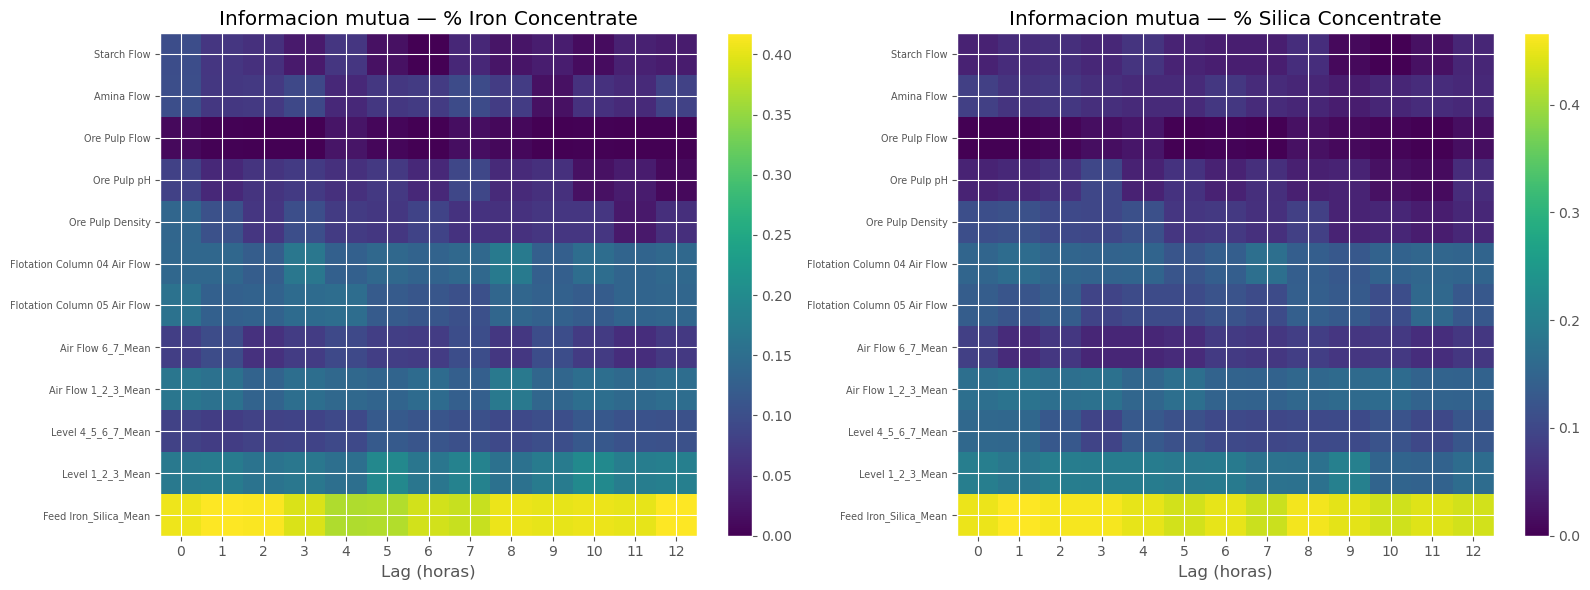

Umbral de ruido (MI, percentil 95 sobre target barajado):
  % Iron Concentrate: 0.0357
  % Silica Concentrate: 0.0398

3 lags plausibles seleccionados (orden de mayor a menor MI validado):
                input  lag               target       mi
Feed Iron_Silica_Mean    1 % Silica Concentrate 0.466244
     Level 1_2_3_Mean    9 % Silica Concentrate 0.202809
  Air Flow 1_2_3_Mean    1 % Silica Concentrate 0.177435


In [111]:
# --- Correlacion cruzada + informacion mutua vs. lag, por señal de entrada ---
# Objetivo: para cada parametro de entrada (solo los "crudos" agregados a la
# hora: sensores + columnas de laboratorio, SIN las features derivadas
# _mean/_slope/_std), ver a que lag esta mas relacionado con cada target y con
# que fuerza, para decidir que lags merece la pena meter como input al modelo.
#
# - Correlacion cruzada (lineal, con signo): corr(input(t-lag), target(t))
# - Informacion mutua (no lineal, sin signo): capta cualquier dependencia,
#   incluida no monotona, pero no dice si la relacion es directa o inversa.
#
# Se usa df_viz (agregacion horaria simple, sin features derivadas) y SOLO el
# tramo de train para no filtrar informacion del test en la seleccion de lags.
from sklearn.feature_selection import mutual_info_regression

MAX_LAG = 12  # horas
input_cols = [c for c in df_viz.columns if c not in TARGET]

train_cutoff = df_viz.index[int(len(df_viz) * 0.70)]
df_viz_train = df_viz.loc[:train_cutoff]

xcorr_results = {t: pd.DataFrame(index=input_cols, columns=range(MAX_LAG + 1), dtype=float) for t in TARGET}
mi_results = {t: pd.DataFrame(index=input_cols, columns=range(MAX_LAG + 1), dtype=float) for t in TARGET}

for target_col in TARGET:
    y = df_viz_train[target_col]
    for lag in range(MAX_LAG + 1):
        shifted = df_viz_train[input_cols].shift(lag)
        valid = shifted.join(y, how='inner').dropna()
        if len(valid) < 30:
            continue
        X_lag = valid[input_cols]
        y_lag = valid[target_col]

        xcorr_results[target_col][lag] = X_lag.corrwith(y_lag)

        mi = mutual_info_regression(X_lag, y_lag, random_state=21)
        mi_results[target_col][lag] = mi

# --- Mejor lag por señal segun cada criterio ---
summary_rows = []
for target_col in TARGET:
    best_xcorr_lag = xcorr_results[target_col].abs().idxmax(axis=1)
    best_xcorr_val = xcorr_results[target_col].abs().max(axis=1)
    best_mi_lag = mi_results[target_col].idxmax(axis=1)
    best_mi_val = mi_results[target_col].max(axis=1)
    for col in input_cols:
        summary_rows.append({
            'target': target_col,
            'input': col,
            'best_lag_xcorr': best_xcorr_lag[col],
            '|xcorr|': best_xcorr_val[col],
            'best_lag_mi': best_mi_lag[col],
            'mi': best_mi_val[col],
        })

summary = pd.DataFrame(summary_rows).sort_values(['target', 'mi'], ascending=[True, False])
print(summary.to_string(index=False))

# --- Heatmaps: fuerza de relacion (MI) por señal x lag, un heatmap por target ---
fig, axes = plt.subplots(1, len(TARGET), figsize=(8 * len(TARGET), 6))
for ax, target_col in zip(axes, TARGET):
    im = ax.imshow(mi_results[target_col].values, aspect='auto', cmap='viridis')
    ax.set_yticks(range(len(input_cols)))
    ax.set_yticklabels(input_cols, fontsize=7)
    ax.set_xticks(range(MAX_LAG + 1))
    ax.set_xlabel('Lag (horas)')
    ax.set_title(f'Informacion mutua — {target_col}')
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# --- Umbral de ruido por permutacion: MI que se obtendria por puro azar ---
# La MI estimada por k-NN nunca es exactamente 0 aunque no haya relacion real,
# asi que no hay un umbral absoluto "bueno". Para saber si un MI observado es
# plausible (no ruido de estimacion) lo comparamos contra la distribucion de MI
# que se obtiene barajando el target (rompe la relacion temporal real) muchas
# veces: cualquier MI observado por debajo del percentil 95 de ese ruido no es
# distinguible de una relacion espuria.
N_PERMUTATIONS = 50
rng = np.random.default_rng(21)
noise_mi = {t: [] for t in TARGET}

for target_col in TARGET:
    y = df_viz_train[target_col].dropna()
    X = df_viz_train.loc[y.index, input_cols]
    for _ in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(y.values)
        mi_noise = mutual_info_regression(X, y_shuffled, random_state=21)
        noise_mi[target_col].append(mi_noise.max())  # el maximo entre señales es el criterio mas estricto

noise_threshold = {t: np.percentile(noise_mi[t], 95) for t in TARGET}
print('Umbral de ruido (MI, percentil 95 sobre target barajado):')
for t in TARGET:
    print(f'  {t}: {noise_threshold[t]:.4f}')

# --- Seleccion final: 3 pares (señal, lag) GLOBALES, señales distintas entre si,
# con MI por encima del umbral de ruido, ordenados de mayor a menor MI. Para
# combinar ambos targets se recorren los candidatos de los dos a la vez y se
# toma, por cada señal, el mejor par (target, lag) que aparezca primero en el
# ranking conjunto.
candidates = []
for target_col in TARGET:
    for col in input_cols:
        for lag in range(MAX_LAG + 1):
            mi_val = mi_results[target_col].loc[col, lag]
            if pd.notna(mi_val) and mi_val >= noise_threshold[target_col]:
                candidates.append({'input': col, 'lag': lag, 'target': target_col, 'mi': mi_val})

candidates_df = pd.DataFrame(candidates).sort_values('mi', ascending=False)

selected = []
used_inputs = set()
for _, row in candidates_df.iterrows():
    if row['input'] in used_inputs:
        continue
    selected.append(row)
    used_inputs.add(row['input'])
    if len(selected) == 3:
        break

selected_lags = pd.DataFrame(selected)[['input', 'lag', 'target', 'mi']].reset_index(drop=True)
print('\n3 lags plausibles seleccionados (orden de mayor a menor MI validado):')
print(selected_lags.to_string(index=False))

In [118]:
# --- 2. Features reducidas: SOLO estas 3, nada mas ---
FEATURE_COLS = [
    'Air Flow 1_2_3_Mean_mean',
    'Level 4_5_6_7_Mean_mean',
    'Amina Flow_mean',
    'Feed Iron_Silica_Mean'
]

# Construir X con lag 1 explicito para TODAS las features (incluido el propio target)
X_all = df[FEATURE_COLS].shift(1)   # todo lo disponible en t-1
X_all.columns = [f"{c}_lag1" for c in X_all.columns]

y_all = df[TARGET].copy()  # target real en t (que tras el shift de X es t = t-1+1)

# Alinear: quitar la primera fila (sin lag disponible) y cualquier NaN por el filtrado de rachas
valid_rows = X_all.dropna().index.intersection(y_all.dropna().index)
X_all = X_all.loc[valid_rows]
y_all = y_all.loc[valid_rows]


In [119]:
from sklearn.multioutput import MultiOutputRegressor

# # Features = everything except the TARGET (TARGET defined above)
# FEATURE_COLS = [c for c in df.columns if c not in TARGET]

# # Forecasting real a HORIZON horas vista: las features de la fila t describen
# # lo que paso HASTA la hora t (sensores + estadisticos de esa hora), y el target
# # es el valor real medido en t+HORIZON. Sin este shift el modelo estaria hackeando
# # el problema (nowcasting: prediciendo el target de la misma hora que sus features).
# X_all = df[FEATURE_COLS]
# y_all = df[TARGET].shift(-HORIZON)
# y_all = y_all.iloc[:-HORIZON]  # las ultimas HORIZON filas no tienen target futuro conocido
# X_all = X_all.loc[y_all.index]

# Recortamos el dataset para que el test acabe el 1 de agosto: a partir de esa
# fecha las condiciones de proceso cambian y dejan de ser comparables a train.
# TEST_CUTOFF = pd.Timestamp('2017-08-01 00:00:00')
# X_all = X_all.loc[:TEST_CUTOFF]
# y_all = y_all.loc[:TEST_CUTOFF]

# Split temporal (no aleatorio) 70/30 dentro del tramo recortado: los datos son
# series temporales, un split aleatorio dejaria que el modelo entrene con
# vecinos temporales del test (fuga de informacion) e invalidaria la
# comparacion contra los naive baselines.
split_idx = int(len(X_all) * 0.70)
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

# z-score normalization: z = (x - mu) / sigma, fit on train only to avoid leakage
X_mean, X_std = X_train.mean(), X_train.std()
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.01,
    random_state=21,
)

model = MultiOutputRegressor(XGBRegressor(**xgb_params, n_jobs=-1, tree_method='hist'))
model.fit(X_train_scaled, y_train)
y_pred_train_model = pd.DataFrame(model.predict(X_train_scaled), index=y_train.index, columns=TARGET)
y_pred_model = pd.DataFrame(model.predict(X_test_scaled), index=y_test.index, columns=TARGET)

print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)
print('Train range:', X_train.index.min(), '->', X_train.index.max())
print('Test range: ', X_test.index.min(), '->', X_test.index.max())
print(f'Target shifted -{HORIZON}h: fila t -> features(t), target = valor real en t+{HORIZON}h')

Train shape: (2762, 4)  Test shape: (1185, 4)
Train range: 2017-03-29 13:00:00 -> 2017-07-22 14:00:00
Test range:  2017-07-22 15:00:00 -> 2017-09-09 23:00:00
Target shifted -1h: fila t -> features(t), target = valor real en t+1h


In [120]:
# --- Grid search de hiperparametros XGBoost con validacion temporal ---
# TimeSeriesSplit en vez de KFold/GridSearchCV aleatorio: cada fold de validacion
# es siempre POSTERIOR en el tiempo a su fold de entrenamiento (igual que el
# split 70/30 de arriba), para no filtrar informacion futura al elegir hiperparametros.
# Se busca solo sobre X_train_scaled/y_train; X_test/y_test se deja intacto para
# la evaluacion final (celdas de naive baselines de mas abajo).
#
# Grid deliberadamente pequeño (3x3x3x2x2 = 108 combinaciones): con ~2760 filas
# de train y 5 folds, cada fold de validacion tiene <500 filas, asi que un grid
# grande solo añade ruido de busqueda sin mejorar la señal.
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'estimator__max_depth': [3, 4, 6],
    'estimator__learning_rate': [0.01, 0.03, 0.1],
    'estimator__n_estimators': [200, 300, 500],
    'estimator__subsample': [0.8, 1.0],
    'estimator__colsample_bytree': [0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=5)

base_estimator = MultiOutputRegressor(
    XGBRegressor(random_state=21, n_jobs=-1, tree_method='hist')
)

# neg_RMSE porque GridSearchCV siempre maximiza el score; con salida multioutput
# sklearn promedia el MSE de las columnas de TARGET antes de invertir el signo.
grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_scaled, y_train)

print('Mejores hiperparametros:', grid_search.best_params_)
print('Mejor RMSE (CV, promedio folds):', -grid_search.best_score_)

# --- Top-10 combinaciones probadas, para ver que tan sensible es el resultado
# a cada hiperparametro (y no quedarnos solo con el ganador puntual) ---
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.sort_values('rank_test_score').head(10).copy()
top10['RMSE_cv'] = -top10['mean_test_score']
print(top10[['rank_test_score', 'RMSE_cv', 'std_test_score', 'params']].to_string(index=False))

# Sustituimos el modelo de la celda anterior por el mejor encontrado en el grid
# search: las celdas de baselines/graficas de abajo siguen funcionando igual
# porque reusan los mismos nombres (model, y_pred_model, y_pred_train_model).
model = grid_search.best_estimator_
y_pred_train_model = pd.DataFrame(model.predict(X_train_scaled), index=y_train.index, columns=TARGET)
y_pred_model = pd.DataFrame(model.predict(X_test_scaled), index=y_test.index, columns=TARGET)

print('\nRMSE test tras grid search:')
for col in TARGET:
    rmse_test = mean_squared_error(y_test[col], y_pred_model[col]) ** 0.5
    print(f'  {col}: {rmse_test:.4f}')


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores hiperparametros: {'estimator__colsample_bytree': 1.0, 'estimator__learning_rate': 0.01, 'estimator__max_depth': 3, 'estimator__n_estimators': 300, 'estimator__subsample': 0.8}
Mejor RMSE (CV, promedio folds): 1.0964110255241395
 rank_test_score  RMSE_cv  std_test_score                                                                                                                                                         params
               1 1.096411        0.132048 {'estimator__colsample_bytree': 1.0, 'estimator__learning_rate': 0.01, 'estimator__max_depth': 3, 'estimator__n_estimators': 300, 'estimator__subsample': 0.8}
               2 1.097878        0.130972 {'estimator__colsample_bytree': 1.0, 'estimator__learning_rate': 0.01, 'estimator__max_depth': 4, 'estimator__n_estimators': 200, 'estimator__subsample': 0.8}
               3 1.099098        0.131614 {'estimator__colsample_bytree': 0.8, 'estimator__learnin

     % Iron Concentrate                                         \
        naive_constante naive_drift xgboost_test xgboost_train   
RMSE           0.779443    1.260576     1.156736      0.969884   
MAE            0.534088    0.887591     0.884461      0.771773   
R2             0.493173   -0.324664    -0.116526      0.238148   

     % Silica Concentrate                                         
          naive_constante naive_drift xgboost_test xgboost_train  
RMSE             0.717634    1.122099     1.109847      0.931675  
MAE              0.432188    0.703277     0.850500      0.737284  
R2               0.607574    0.041352     0.060683      0.304671  


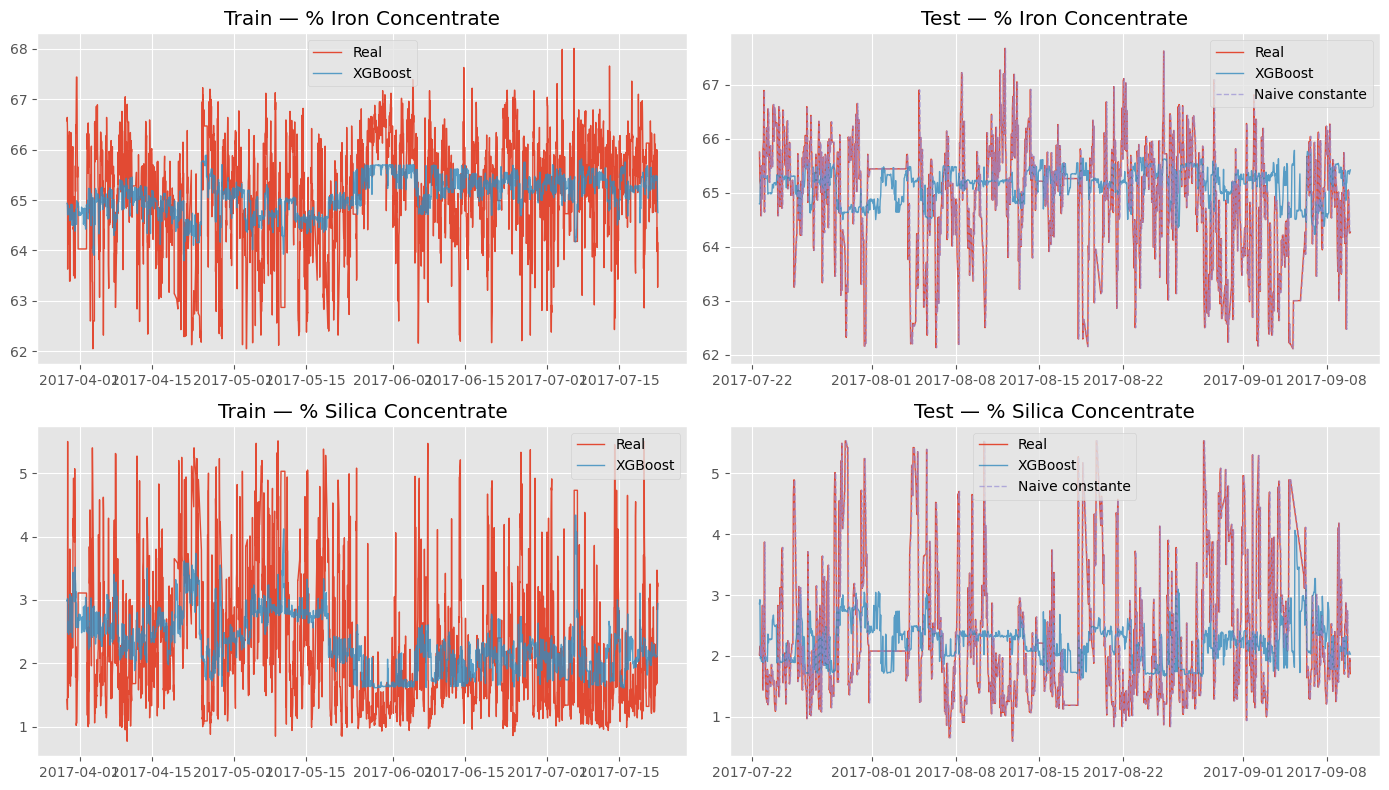

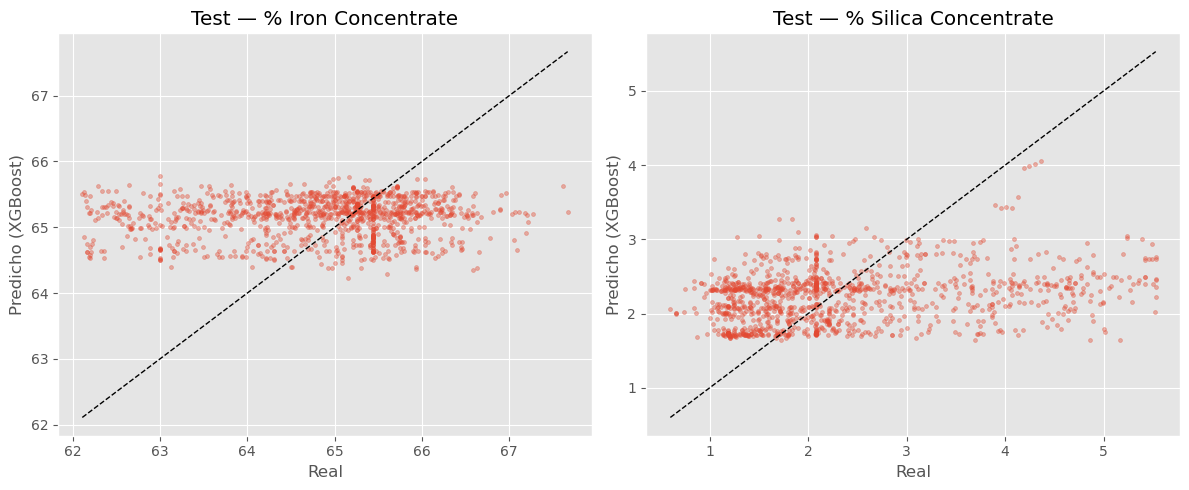

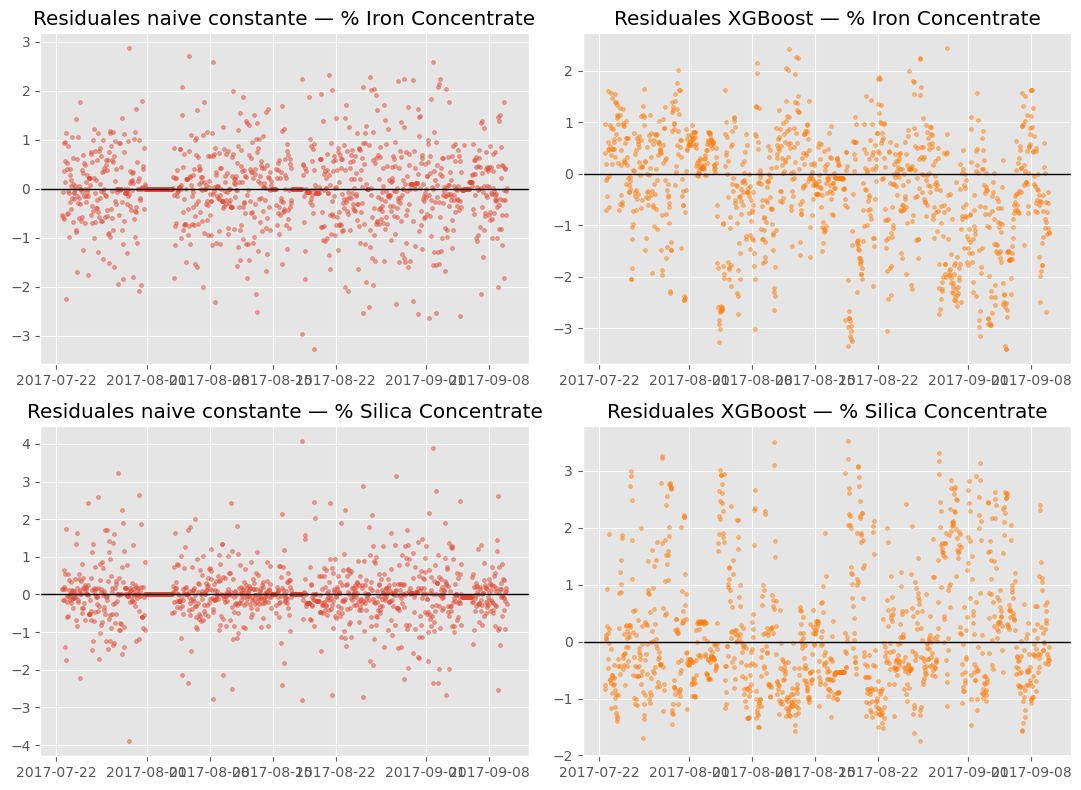

In [121]:
# --- Naive baselines realimentados (persistencia clasica de forecasting a 1 paso):
# usan el valor REAL del target en t (y t-1 para el drift) para predecir t+1, a
# diferencia de un naive "ciego" que no se realimenta. Se evalua sobre el tramo
# de test en resolucion horaria SIN desplazar (df[TARGET], no y_test que ya esta
# shiftado -HORIZON para el XGBoost).
target_series_test = df.loc[X_test.index.min():X_test.index.max(), TARGET]

# ============================================================
# NAIVE CONSTANTE (persistencia): pred(t+1) = target(t)
# ============================================================
def evaluate_naive_constant(df_eval, target_col):
    y_true = df_eval[target_col].iloc[1:].values          # valores reales en t+1
    y_pred = df_eval[target_col].iloc[:-1].values          # prediccion = valor en t
    return y_true, y_pred

# ============================================================
# NAIVE CON DRIFT: pred(t+1) = target(t) + [target(t) - target(t-1)]
# Requiere al menos 2 puntos de historia antes de poder predecir
# ============================================================
def evaluate_naive_drift(df_eval, target_col):
    y = df_eval[target_col].values
    y_true = y[2:]                          # valor real en t+1, empezando desde el 3er punto
    y_t     = y[1:-1]                       # valor en t
    y_t_1   = y[0:-2]                       # valor en t-1
    y_pred  = y_t + (y_t - y_t_1)           # persistencia + tendencia del paso anterior
    return y_true, y_pred

# --- Metricas: RMSE, MAE y R^2 (nunca solo R^2, como exige el criterio del proyecto) ---
naive_results = {}
for col in TARGET:
    yt_c, yp_c = evaluate_naive_constant(target_series_test, col)
    yt_d, yp_d = evaluate_naive_drift(target_series_test, col)

    naive_results[col] = {
        'naive_constante': {
            'RMSE': mean_squared_error(yt_c, yp_c) ** 0.5,
            'MAE': mean_absolute_error(yt_c, yp_c),
            'R2': r2_score(yt_c, yp_c),
        },
        'naive_drift': {
            'RMSE': mean_squared_error(yt_d, yp_d) ** 0.5,
            'MAE': mean_absolute_error(yt_d, yp_d),
            'R2': r2_score(yt_d, yp_d),
        },
        'xgboost_test': {
            'RMSE': mean_squared_error(y_test[col], y_pred_model[col]) ** 0.5,
            'MAE': mean_absolute_error(y_test[col], y_pred_model[col]),
            'R2': r2_score(y_test[col], y_pred_model[col]),
        },
        'xgboost_train': {
            'RMSE': mean_squared_error(y_train[col], y_pred_train_model[col]) ** 0.5,
            'MAE': mean_absolute_error(y_train[col], y_pred_train_model[col]),
            'R2': r2_score(y_train[col], y_pred_train_model[col]),
        },
    }

results = pd.DataFrame({(t, m): naive_results[t][m] for t in naive_results for m in naive_results[t]})
print(results)

# Predicciones naive realineadas al indice del target (para graficar junto al XGBoost)
y_pred_naive_const = pd.DataFrame(
    {col: evaluate_naive_constant(target_series_test, col)[1] for col in TARGET},
    index=target_series_test.index[1:],
)

# --- Graficas de prediccion: real vs. predicho, train y test, por target ---
fig, axes = plt.subplots(len(TARGET), 2, figsize=(14, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    axes[i, 0].plot(y_train.index, y_train[col], label='Real', linewidth=1)
    axes[i, 0].plot(y_pred_train_model.index, y_pred_train_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    axes[i, 0].set_title(f'Train — {col}')
    axes[i, 0].legend()

    axes[i, 1].plot(y_test.index, y_test[col], label='Real', linewidth=1)
    axes[i, 1].plot(y_pred_model.index, y_pred_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    axes[i, 1].plot(y_pred_naive_const.index, y_pred_naive_const[col], label='Naive constante', linewidth=1, linestyle='--', alpha=0.7)
    axes[i, 1].set_title(f'Test — {col}')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

# --- Scatter real vs. predicho (test), por target ---
fig, axes = plt.subplots(1, len(TARGET), figsize=(6 * len(TARGET), 5))
for i, col in enumerate(TARGET):
    ax = axes[i]
    ax.scatter(y_test[col], y_pred_model[col], s=8, alpha=0.4)
    lims = [min(y_test[col].min(), y_pred_model[col].min()), max(y_test[col].max(), y_pred_model[col].max())]
    ax.plot(lims, lims, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicho (XGBoost)')
    ax.set_title(f'Test — {col}')

plt.tight_layout()
plt.show()

# --- Residual plots: modelo vs. naive constante, para cada target ---
fig, axes = plt.subplots(len(TARGET), 2, figsize=(11, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    resid_naive = target_series_test[col].iloc[1:].values - y_pred_naive_const[col].values
    resid_model = y_test[col] - y_pred_model[col]

    axes[i, 0].scatter(y_pred_naive_const.index, resid_naive, s=8, alpha=0.5)
    axes[i, 0].axhline(0, color='black', linewidth=1)
    axes[i, 0].set_title(f'Residuales naive constante — {col}')

    axes[i, 1].scatter(y_test.index, resid_model, s=8, alpha=0.5, color='tab:orange')
    axes[i, 1].axhline(0, color='black', linewidth=1)
    axes[i, 1].set_title(f'Residuales XGBoost — {col}')

plt.tight_layout()
plt.show()

In [122]:
# --- LSTM (Keras) sobre las mismas 4 variables de entrada que XGBoost ---
# Reusa X_train_scaled/X_test_scaled/y_train/y_test tal cual los dejo el bloque
# de XGBoost: mismas features (FEATURE_COLS, todas en t-1), mismo target (TARGET,
# valor real en t), mismo split temporal 70/30 y mismo escalado (z-score fit en
# train). Unico paso extra: dar forma 3D [samples, timesteps, features] a X,
# como pide Keras. Aqui timesteps=1 porque solo tenemos un lag (t-1) por variable.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

n_targets_lstm = len(TARGET)
n_features_lstm = X_train_scaled.shape[1]  # 4: las columnas de FEATURE_COLS con lag1

train_X_lstm = X_train_scaled.values.reshape((X_train_scaled.shape[0], 1, n_features_lstm))
test_X_lstm = X_test_scaled.values.reshape((X_test_scaled.shape[0], 1, n_features_lstm))
train_y_lstm = y_train.values
test_y_lstm = y_test.values

print(f'train_X_lstm: {train_X_lstm.shape}, train_y_lstm: {train_y_lstm.shape}')
print(f'test_X_lstm : {test_X_lstm.shape}, test_y_lstm : {test_y_lstm.shape}')

lstm_model = Sequential([
    LSTM(units=16,
         return_sequences=True,
         input_shape=(train_X_lstm.shape[1], train_X_lstm.shape[2])),
    LSTM(units=16),
    Dense(n_targets_lstm)   # una salida por target: [Iron, Silica]
])
lstm_model.compile(
    loss='mae',
    optimizer='adam')
lstm_model.summary()

history = lstm_model.fit(
    train_X_lstm,
    train_y_lstm,
    epochs=100,
    batch_size=16,
    validation_data=(test_X_lstm, test_y_lstm),
    verbose=2,
    shuffle=False,
    callbacks=[
        ModelCheckpoint('./LSTM_Flotation_ML.keras', save_best_only=True),
        EarlyStopping(patience=15, restore_best_weights=True),
    ])


train_X_lstm: (2762, 1, 4), train_y_lstm: (2762, 2)
test_X_lstm : (1185, 1, 4), test_y_lstm : (1185, 2)


c:\Users\COMPUTAEX\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 16)          │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,490 (13.63 KB)

 Trainable params: 3,490 (13.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
173/173 - 3s - 19ms/step - loss: 33.4712 - val_loss: 32.8816
Epoch 2/100
173/173 - 1s - 3ms/step - loss: 31.8922 - val_loss: 30.4728
Epoch 3/100
173/173 - 1s - 3ms/step - loss: 29.0862 - val_loss: 27.4679
Epoch 4/100
173/173 - 0s - 3ms/step - loss: 26.3920 - val_loss: 25.1606
Epoch 5/100
173/173 - 1s - 3ms/step - loss: 24.3301 - val_loss: 23.3031
Epoch 6/100
173/173 - 0s - 3ms/step - loss: 22.6225 - val_loss: 21.7336
Epoch 7/100
173/173 - 1s - 4ms/step - loss: 21.1376 - val_loss: 20.3144
Epoch 8/100
173/173 - 0s - 3ms/step - loss: 19.7653 - val_loss: 18.9785
Epoch 9/100
173/173 - 1s - 3ms/step - loss: 18.4572 - val_loss: 17.6931
Epoch 10/100
173/173 - 0s - 3ms/step - loss: 17.1901 - val_loss: 16.4416
Epoch 11/100
173/173 - 0s - 3ms/step - loss: 15.9521 - val_loss: 15.2128
Epoch 12/100
173/173 - 0s - 3ms/step - loss: 14.7338 - val_loss: 14.0028
Epoch 13/100
173/173 - 0s - 3ms/step - loss: 13.5311 - val_loss: 12.8069
Epoch 14/100
173/173 - 1s - 3ms/step - loss: 12.3406 - val_

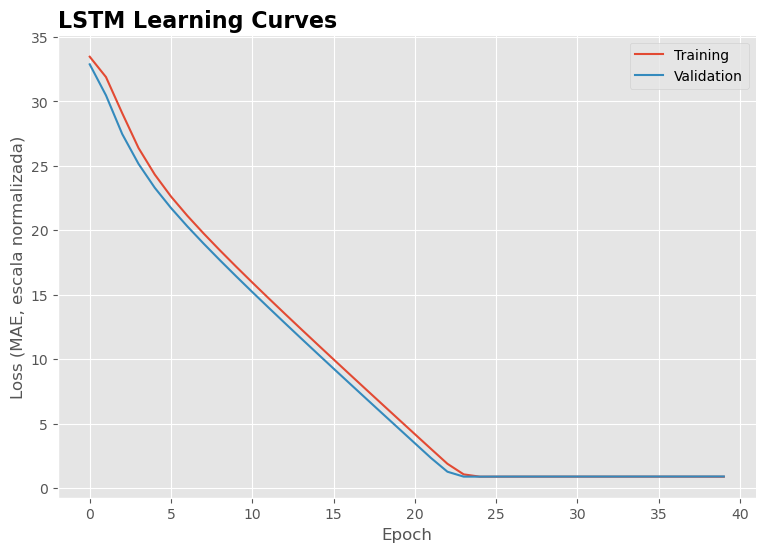

Best training loss   = 0.8835 at epoch 39
Best validation loss = 0.8895 at epoch 24


In [123]:
# --- Curvas de aprendizaje ---
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_loss, label='Training')
ax.plot(val_loss, label='Validation')
ax.set_title('LSTM Learning Curves', loc='left', weight='bold', size=16)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MAE, escala normalizada)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

print(f'Best training loss   = {min(train_loss):.4f} at epoch {train_loss.index(min(train_loss))}')
print(f'Best validation loss = {min(val_loss):.4f} at epoch {val_loss.index(min(val_loss))}')

In [124]:
# --- Prediccion y metricas LSTM, mismas metricas y mismo formato que XGBoost/naive ---
# Nota: train_y_lstm/test_y_lstm ya estan en la escala ORIGINAL del target (no
# se normalizo y_train/y_test, igual que en el bloque de XGBoost), asi que no
# hace falta inverse_transform aqui -- la salida del modelo se compara directo.
y_pred_train_lstm = pd.DataFrame(lstm_model.predict(train_X_lstm), index=y_train.index, columns=TARGET)
y_pred_test_lstm = pd.DataFrame(lstm_model.predict(test_X_lstm), index=y_test.index, columns=TARGET)

lstm_results = {}
for col in TARGET:
    lstm_results[col] = {
        'lstm_train': {
            'RMSE': mean_squared_error(y_train[col], y_pred_train_lstm[col]) ** 0.5,
            'MAE': mean_absolute_error(y_train[col], y_pred_train_lstm[col]),
            'R2': r2_score(y_train[col], y_pred_train_lstm[col]),
        },
        'lstm_test': {
            'RMSE': mean_squared_error(y_test[col], y_pred_test_lstm[col]) ** 0.5,
            'MAE': mean_absolute_error(y_test[col], y_pred_test_lstm[col]),
            'R2': r2_score(y_test[col], y_pred_test_lstm[col]),
        },
    }

lstm_results_df = pd.DataFrame({(t, m): lstm_results[t][m] for t in lstm_results for m in lstm_results[t]})
print(lstm_results_df)

87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
     % Iron Concentrate           % Silica Concentrate          
             lstm_train lstm_test           lstm_train lstm_test
RMSE           1.123555  1.179924             1.259637  1.309579
MAE            0.884876  0.870113             0.887879  0.908934
R2            -0.022397 -0.161737            -0.271020 -0.307825


                                          RMSE       MAE        R2
target               method                                       
% Iron Concentrate   naive_constante  0.779443  0.534088  0.493173
                     naive_drift      1.260576  0.887591 -0.324664
                     xgboost_test     1.156736  0.884461 -0.116526
                     lstm_test        1.179924  0.870113 -0.161737
% Silica Concentrate naive_constante  0.717634  0.432188  0.607574
                     naive_drift      1.122099  0.703277  0.041352
                     xgboost_test     1.109847  0.850500  0.060683
                     lstm_test        1.309579  0.908934 -0.307825


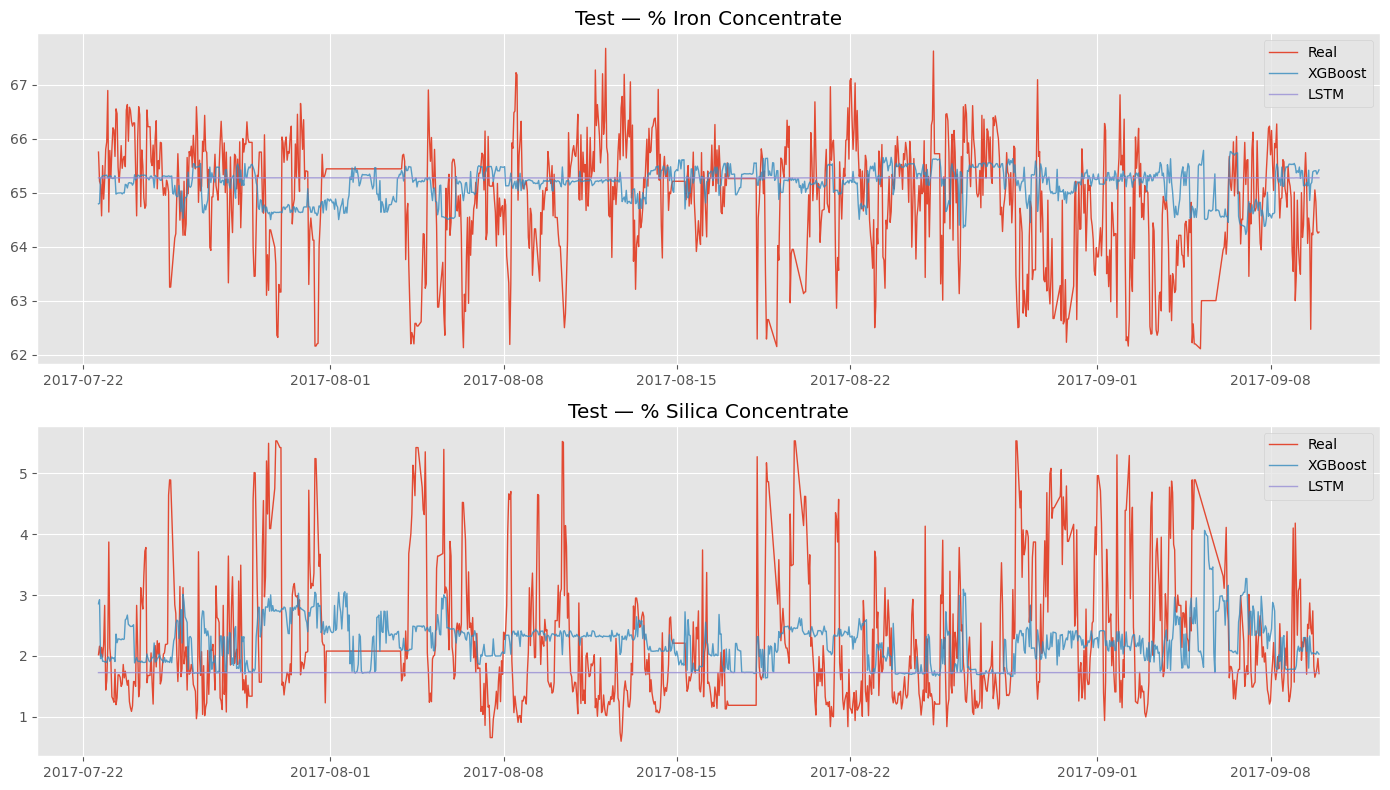

In [125]:
# --- Comparativa final: LSTM vs. XGBoost vs. naive baselines (test), por target ---
# Reusa xgboost_test/naive_constante/naive_drift ya calculados en naive_results
# (celda anterior) para no repetir esos calculos.
comparison_rows = []
for col in TARGET:
    for method, metrics in [
        ('naive_constante', naive_results[col]['naive_constante']),
        ('naive_drift', naive_results[col]['naive_drift']),
        ('xgboost_test', naive_results[col]['xgboost_test']),
        ('lstm_test', lstm_results[col]['lstm_test']),
    ]:
        comparison_rows.append({'target': col, 'method': method, **metrics})

comparison_df = pd.DataFrame(comparison_rows).set_index(['target', 'method'])
print(comparison_df)

# --- Graficas: real vs. predicho (test), LSTM vs. XGBoost, por target ---
fig, axes = plt.subplots(len(TARGET), 1, figsize=(14, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    ax = axes[i] if len(TARGET) > 1 else axes
    ax.plot(y_test.index, y_test[col], label='Real', linewidth=1)
    ax.plot(y_pred_model.index, y_pred_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    ax.plot(y_pred_test_lstm.index, y_pred_test_lstm[col], label='LSTM', linewidth=1, alpha=0.8)
    ax.set_title(f'Test — {col}')
    ax.legend()

plt.tight_layout()
plt.show()